# Setup
Always run this

In [30]:
import numpy as np
import pandas as pd
import mir_eval
from music21 import key, scale
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
plt.style.use('seaborn-v0_8')

In [31]:
ROOTS = ['C', 'Db', 'D', 'Eb', 'E', 'F', 'F#', 'G', 'Ab', 'A', 'Bb', 'B']

def normalize_key(key_str):
    """
    Convert a key string to a canonical form.
    E.g., "Gb major" -> "F# major"
    Enharmonically equivalent keys map to the same representation.
    """
    try:
        raw_tonic, raw_mode = key_str.split()
        k = key.Key(raw_tonic, raw_mode.lower())
        # Get the pitch and convert to sharp representation (canonical form)
        tonic = k.tonic
        pc = tonic.pitchClass  # 0-11 representing pitch class

        canonical_tonic = ROOTS[pc]
        mode = k.mode.lower()
        
        return f"{canonical_tonic} {mode}"
    except Exception as e:
        print(e)

In [32]:
fmak_df = pd.read_csv("../fma-keys/fmakv2.csv")
track_ids = fmak_df["track_id"].tolist()
actual_keys_dict = dict(zip(track_ids, fmak_df["key_and_mode"]))
actual_keys = [normalize_key(actual_keys_dict[tid]) for tid in track_ids]

In [33]:
def get_avg_weighted_score(y_true, y_pred):
    """
    Calculates the MIREX weighted score for each prediction and returns the average score across all predictions.

    See mirex website for more details: https://music-ir.org/mirex/wiki/2025:Audio_Key_Detection
    """
    cumulative_score = 0.0

    for true, pred in zip(y_true, y_pred):
        weighted_score = mir_eval.key.weighted_score(true, pred)
        cumulative_score += weighted_score

    avg_score = cumulative_score / len(y_true)
    return avg_score

def get_metrics(predicted_keys, true_keys):
    """
    Computes various evaluation metrics for key estimation.
    """
    return {
        'Accuracy': accuracy_score(true_keys, predicted_keys),
        'Precision (Macro)': precision_score(true_keys, predicted_keys, average='macro'),
        'Recall (Macro)': recall_score(true_keys, predicted_keys, average='macro'),
        'F1 Score (Macro)': f1_score(true_keys, predicted_keys, average='macro'),
        'Average MIREX Score': get_avg_weighted_score(true_keys, predicted_keys),
    }

def print_metrics(metrics):
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

In [34]:
def _build_key_distance_matrix() -> dict[tuple[str, str], int]:
    all_keys = [f"{r} {m}" for r in ROOTS for m in ('major', 'minor')]

    def _pitch_classes(k: key.Key) -> frozenset[int]:
        s = scale.MinorScale(k.tonic) if k.mode == 'minor' else scale.MajorScale(k.tonic)
        return frozenset(p.pitchClass for p in s.getPitches()[:-1])

    pcs = {k: _pitch_classes(key.Key(*k.split())) for k in all_keys}
    return {(k1, k2): 7 - len(pcs[k1] & pcs[k2]) for k1 in all_keys for k2 in all_keys}

_KEY_DISTANCE = _build_key_distance_matrix()

def get_key_distance(key1: str, key2: str) -> int:
    """Number of notes that differ between two keys. Uses natural minor for minor keys."""
    return _KEY_DISTANCE[(normalize_key(key1), normalize_key(key2))]

def plot_key_distance_distribution(predicted_keys, true_keys):
    # Calculate key distance distributions
    key_distances = [get_key_distance(pred, true) for pred, true in zip(predicted_keys, true_keys)]
    key_dist_counter = Counter(key_distances)

    # Convert to proportions
    total = len(key_distances)
    key_proportions = [key_dist_counter.get(d, 0) / total for d in key_dist_counter]


    # Create grouped bar chart
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(6)
    width = 0.25

    ax.bar(x, key_proportions, width)

    ax.set_xlabel('Key Distance')
    ax.set_ylabel('Proportion')
    ax.set_title('Distance from True Key')
    ax.set_xticks(x)

    plt.tight_layout()
    plt.show()

In [35]:
def is_relative_key(key1: str, key2: str) -> bool:
    """Check if two keys are relative (same key signature)."""
    return get_key_distance(key1, key2) == 0 and normalize_key(key1) != normalize_key(key2)

def is_parallel_key(key1: str, key2: str) -> bool:
    """Check if two keys are parallel (same tonic)."""
    k1_norm = normalize_key(key1)
    k2_norm = normalize_key(key2)
    return k1_norm.split()[0] == k2_norm.split()[0] and k1_norm.split()[1] != k2_norm.split()[1]

def get_num_total_errors(predicted_keys, true_keys):
    return sum(1 for pred, true in zip(predicted_keys, true_keys) if pred != true)

def get_relative_key_error_proportion(predicted_keys, true_keys):
    is_relative_error = [is_relative_key(pred, true) for pred, true in zip(predicted_keys, true_keys)]
    num_relative_errors = sum(is_relative_error)
    num_total_errors = get_num_total_errors(predicted_keys, true_keys)
    return num_relative_errors / num_total_errors if num_total_errors > 0 else 0

def get_parallel_key_error_proportion(predicted_keys, true_keys):
    is_parallel_error = [is_parallel_key(pred, true) for pred, true in zip(predicted_keys, true_keys)]
    num_parallel_errors = sum(is_parallel_error)
    num_total_errors = get_num_total_errors(predicted_keys, true_keys)
    return num_parallel_errors / num_total_errors if num_total_errors > 0 else 0

# Baseline (AllConv) Eval

In [36]:
allconv_df = pd.read_csv("../baseline/allconv-predictions.csv")
allconv_keys_dict = dict(zip(allconv_df["track_id"], allconv_df["key"]))
allconv_keys = [normalize_key(allconv_keys_dict[tid]) for tid in track_ids]

In [37]:
allconv_metrics = get_metrics(allconv_keys, actual_keys)
print_metrics(allconv_metrics)

Accuracy: 0.6617
Precision (Macro): 0.6476
Recall (Macro): 0.6434
F1 Score (Macro): 0.6429
Average MIREX Score: 0.7211


In [39]:
print(get_relative_key_error_proportion(allconv_keys, actual_keys))
print(get_parallel_key_error_proportion(allconv_keys, actual_keys))

0.25848142164781907
0.0990845449649973


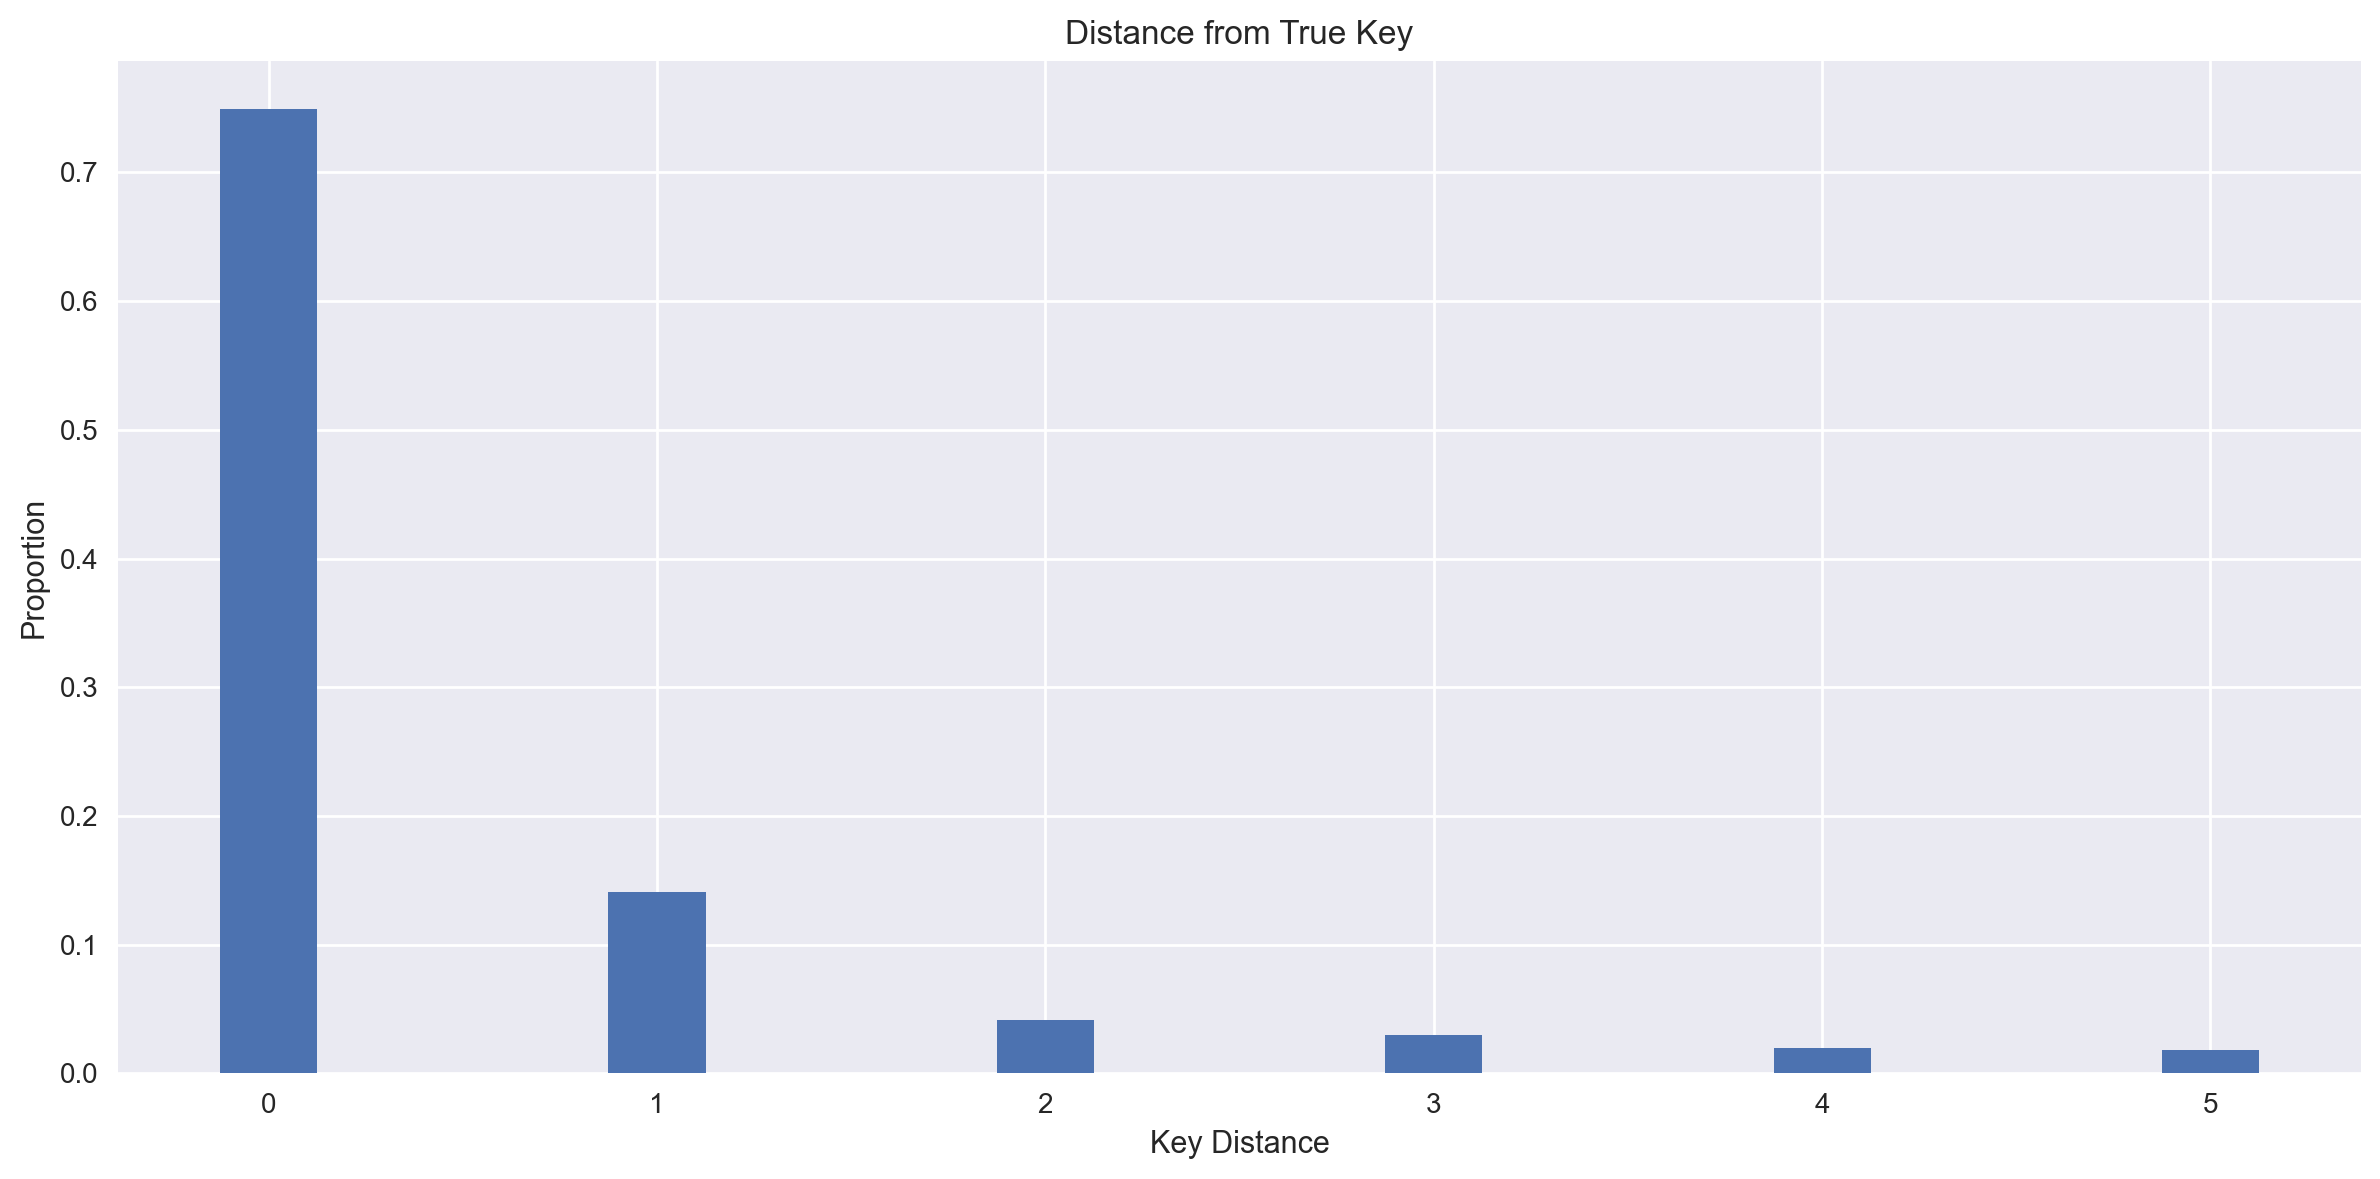

In [38]:
plot_key_distance_distribution(allconv_keys, actual_keys)